In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the file
df = pd.read_csv('phase1_results.csv')

# --- CRITICAL STEP: Calculate Throughput ---
# Formula: (Number of elements / (Time in ms / 1000)) / 1 million
df['Throughput_Naive'] = (df['Size'] / (df['GPU_Naive_ms'] / 1000.0)) / 1e6
df['Throughput_Thrust'] = (df['Size'] / (df['GPU_Lib_ms'] / 1000.0)) / 1e6

# Calculate Speedup relative to CPU for your report
df['Speedup'] = df['CPU_ms'] / df['GPU_Naive_ms']

print(f"Loaded {len(df)} scaling data points.")
print(df[['Size', 'Throughput_Naive', 'Throughput_Thrust']].tail())

Loaded 16 scaling data points.
        Size  Throughput_Naive  Throughput_Thrust
11   2097152        172.259167        4946.859903
12   4194304        262.544380        7062.068966
13   8388608        328.640246        9051.933702
14  16777216        431.364087       11669.483202
15  33554432        491.118329       13624.948025


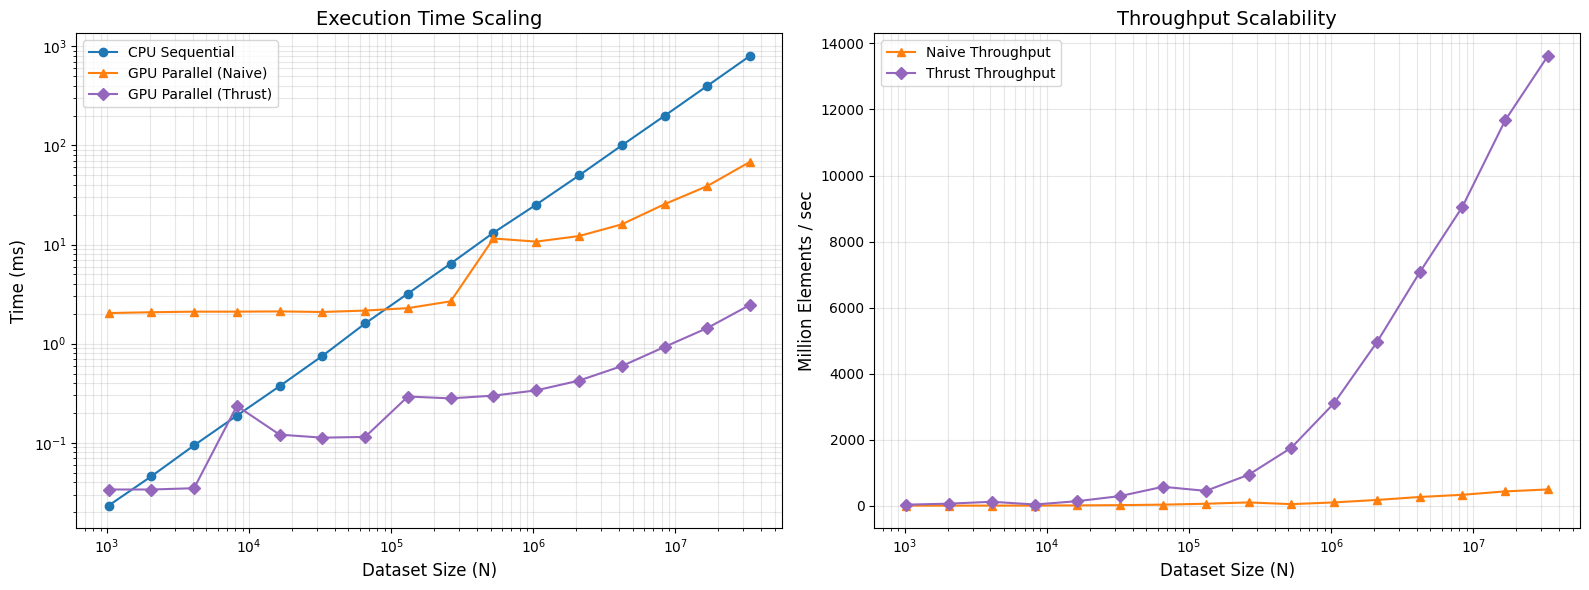

In [2]:
# 1. Define the Global Visual Style
COLORS = {
    'CPU': 'tab:blue',
    'Naive': 'tab:orange', 
    'Thrust': 'tab:purple'
}

MARKERS = {
    'CPU': 'o',
    'Naive': '^',
    'Thrust': 'D'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Execution Time (Log-Log) ---
ax1.loglog(df['Size'], df['CPU_ms'], 
           label='CPU Sequential', color=COLORS['CPU'], marker=MARKERS['CPU'])

ax1.loglog(df['Size'], df['GPU_Naive_ms'], 
           label='GPU Parallel (Naive)', color=COLORS['Naive'], marker=MARKERS['Naive'])

ax1.loglog(df['Size'], df['GPU_Lib_ms'], 
           label='GPU Parallel (Thrust)', color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax1.set_title('Execution Time Scaling', fontsize=14)
ax1.set_xlabel('Dataset Size (N)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# --- Subplot 2: Throughput (Linear-Log) ---
# Note: CPU is often left off throughput charts as it's too low to see, 
# but you can add it using COLORS['CPU'] if you want the comparison!
ax2.semilogx(df['Size'], df['Throughput_Naive'], 
             label='Naive Throughput', color=COLORS['Naive'], marker=MARKERS['Naive'])

ax2.semilogx(df['Size'], df['Throughput_Thrust'], 
             label='Thrust Throughput', color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax2.set_title('Throughput Scalability', fontsize=14)
ax2.set_xlabel('Dataset Size (N)', fontsize=12)
ax2.set_ylabel('Million Elements / sec', fontsize=12)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Updated filename for Phase 2
df = pd.read_csv('phase2_results.csv')

# Calculate Throughput for all versions
# Formula: (N / (ms / 1000)) / 1e6
df['Throughput_Naive'] = (df['Size'] / (df['GPU_Naive_ms'] / 1000.0)) / 1e6
df['Throughput_Opt'] = (df['Size'] / (df['GPU_Opt_ms'] / 1000.0)) / 1e6
df['Throughput_Thrust'] = (df['Size'] / (df['GPU_Lib_ms'] / 1000.0)) / 1e6

# Calculate the Speedup of Optimized vs Naive
df['Opt_vs_Naive_Speedup'] = df['GPU_Naive_ms'] / df['GPU_Opt_ms']

print(f"Phase 2 Data Loaded: {len(df)} points.")
print(f"Max Speedup (Opt vs Naive): {df['Opt_vs_Naive_Speedup'].max():.2f}x")

Phase 2 Data Loaded: 16 points.
Max Speedup (Opt vs Naive): 64.84x


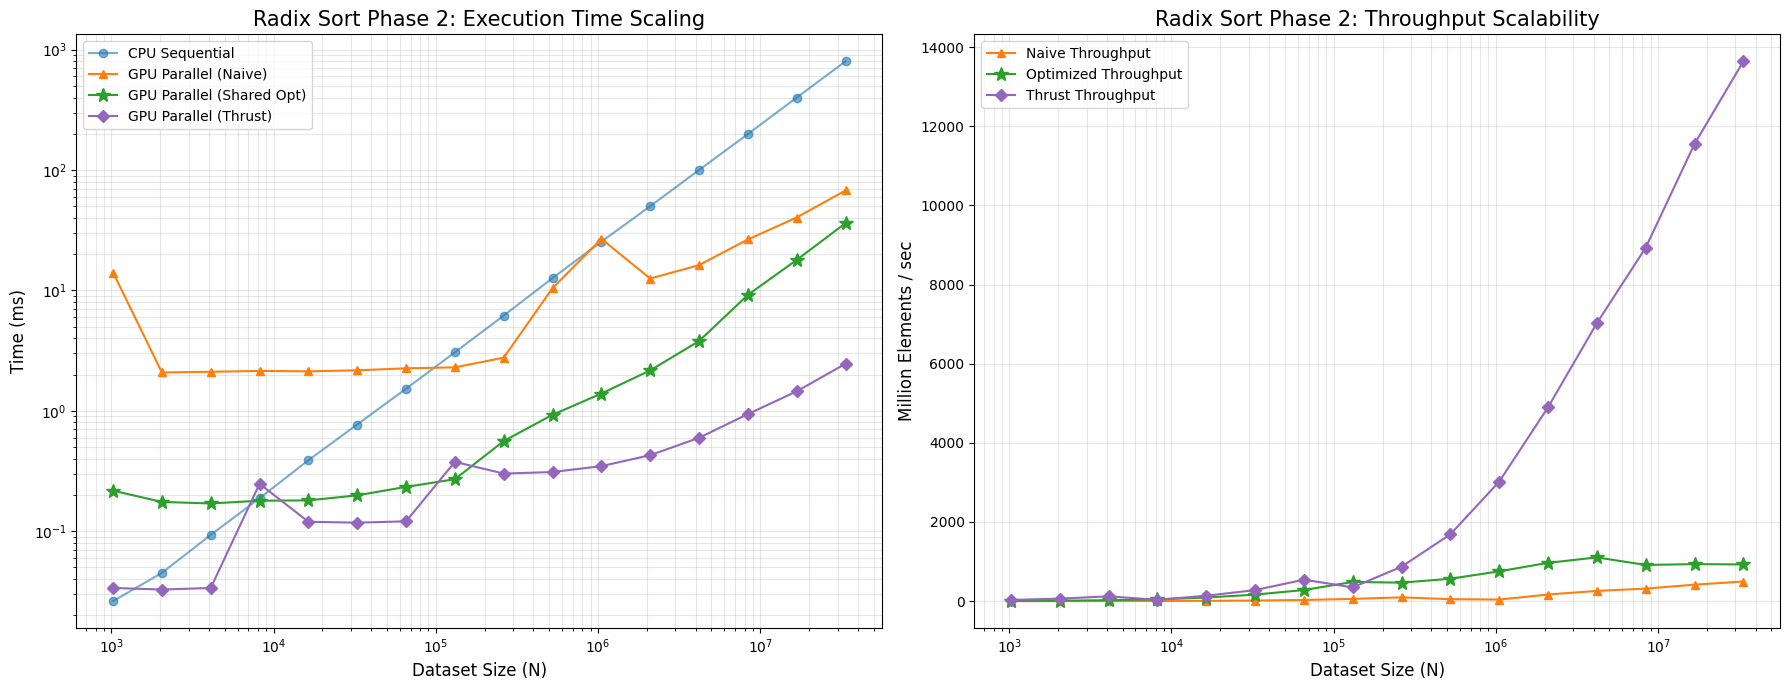

In [ ]:
# Updated Visual Style
COLORS = {
    'CPU': 'tab:blue',
    'Naive': 'tab:orange', 
    'Optimized': 'tab:green',  # Green signifies the successful Phase 2 optimization
    'Thrust': 'tab:purple'
}

MARKERS = {
    'CPU': 'o',
    'Naive': '^',
    'Optimized': '*', # Star marker to make it stand out
    'Thrust': 'D'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Execution Time (Log-Log) ---
ax1.loglog(df['Size'], df['CPU_ms'], label='CPU Sequential', 
           color=COLORS['CPU'], marker=MARKERS['CPU'], alpha=0.6)

ax1.loglog(df['Size'], df['GPU_Naive_ms'], label='GPU Parallel (Naive)', 
           color=COLORS['Naive'], marker=MARKERS['Naive'])

ax1.loglog(df['Size'], df['GPU_Opt_ms'], label='GPU Parallel (Shared Opt)', 
           color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)

ax1.loglog(df['Size'], df['GPU_Lib_ms'], label='GPU Parallel (Thrust)', 
           color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax1.set_title('Radix Sort Phase 2: Execution Time Scaling', fontsize=15)
ax1.set_xlabel('Dataset Size (N)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# --- Subplot 2: Throughput Scalability (Linear-Log) ---
ax2.semilogx(df['Size'], df['Throughput_Naive'], label='Naive Throughput', 
             color=COLORS['Naive'], marker=MARKERS['Naive'])

ax2.semilogx(df['Size'], df['Throughput_Opt'], label='Optimized Throughput', 
             color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)

ax2.semilogx(df['Size'], df['Throughput_Thrust'], label='Thrust Throughput', 
             color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax2.set_title('Radix Sort Phase 2: Throughput Scalability', fontsize=15)
ax2.set_xlabel('Dataset Size (N)', fontsize=12)
ax2.set_ylabel('Million Elements / sec', fontsize=12)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
# Updated filename for Phase 3
df = pd.read_csv('phase3_results.csv')

# Calculate Throughput for all versions
# Formula: (N / (ms / 1000)) / 1e6
df['Throughput_Naive'] = (df['Size'] / (df['GPU_Naive_ms'] / 1000.0)) / 1e6
df['Throughput_Opt'] = (df['Size'] / (df['GPU_Opt_ms'] / 1000.0)) / 1e6
df['Throughput_Thrust'] = (df['Size'] / (df['GPU_Lib_ms'] / 1000.0)) / 1e6

# Calculate the Speedup of Optimized vs Naive
df['Opt_vs_Naive_Speedup'] = df['GPU_Naive_ms'] / df['GPU_Opt_ms']

print(f"Phase 3 Data Loaded: {len(df)} points.")
print(f"Max Speedup (Opt vs Naive): {df['Opt_vs_Naive_Speedup'].max():.2f}x")

Phase 3 Data Loaded: 16 points.
Max Speedup (Opt vs Naive): 16.98x


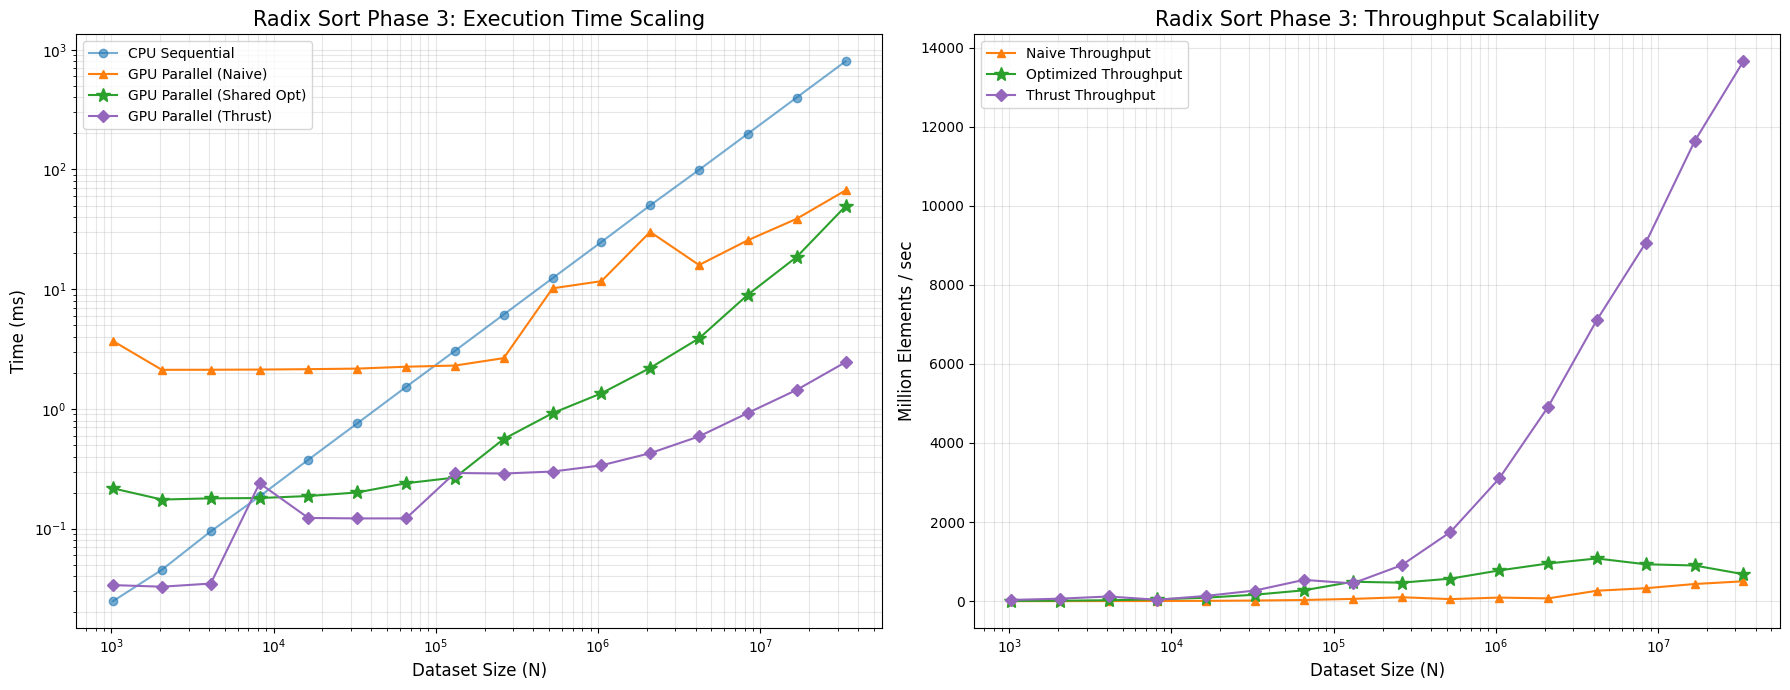

In [6]:
# Updated Visual Style
COLORS = {
    'CPU': 'tab:blue',
    'Naive': 'tab:orange', 
    'Optimized': 'tab:green',  # Green signifies the successful Phase 2 optimization
    'Thrust': 'tab:purple'
}

MARKERS = {
    'CPU': 'o',
    'Naive': '^',
    'Optimized': '*', # Star marker to make it stand out
    'Thrust': 'D'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Execution Time (Log-Log) ---
ax1.loglog(df['Size'], df['CPU_ms'], label='CPU Sequential', 
           color=COLORS['CPU'], marker=MARKERS['CPU'], alpha=0.6)

ax1.loglog(df['Size'], df['GPU_Naive_ms'], label='GPU Parallel (Naive)', 
           color=COLORS['Naive'], marker=MARKERS['Naive'])

ax1.loglog(df['Size'], df['GPU_Opt_ms'], label='GPU Parallel (Shared Opt)', 
           color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)

ax1.loglog(df['Size'], df['GPU_Lib_ms'], label='GPU Parallel (Thrust)', 
           color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax1.set_title('Radix Sort Phase 3: Execution Time Scaling', fontsize=15)
ax1.set_xlabel('Dataset Size (N)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# --- Subplot 2: Throughput Scalability (Linear-Log) ---
ax2.semilogx(df['Size'], df['Throughput_Naive'], label='Naive Throughput', 
             color=COLORS['Naive'], marker=MARKERS['Naive'])

ax2.semilogx(df['Size'], df['Throughput_Opt'], label='Optimized Throughput', 
             color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)

ax2.semilogx(df['Size'], df['Throughput_Thrust'], label='Thrust Throughput', 
             color=COLORS['Thrust'], marker=MARKERS['Thrust'])

ax2.set_title('Radix Sort Phase 3: Throughput Scalability', fontsize=15)
ax2.set_xlabel('Dataset Size (N)', fontsize=12)
ax2.set_ylabel('Million Elements / sec', fontsize=12)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()